# 3.1 El Modelo Multidimensional: Construyendo el Espacio
Dejemos atrás las tablas. Vamos a crear un Espacio Vectorial usando `numpy` y `pandas` para entender cómo los modelos de aprendizaje "observa" a nuestros usuarios.

## Formalización

De acuerdo con la literatura matemática estándar, a partir de hoy dejaremos de llamarles 'tablas'. Las llamaremos Matrices de Características (Feature Matrices).

$$\mathbf{X} \in \mathbb{R}^{n \times p}$$
Donde:
* $n$: Representa el número total de observaciones (sus usuarios o filas).
* $p$: Representa la dimensionalidad del espacio (sus variables, features o columnas).

$$\mathbf{X} = \begin{pmatrix} x_{11} & x_{12} & \dots & x_{1p} \\ x_{21} & x_{22} & \dots & x_{2p} \\ \vdots & \vdots & \ddots & \vdots \\ x_{n1} & x_{n2} & \dots & x_{np} \end{pmatrix}$$

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definimos las dimensiones del modelo (Notación ISLP)
n = 5 # Número de observaciones (Usuarios)
p = 3 # Dimensionalidad (Features: Edad, Salario_USD, Engagement_Score)

# Construimos la Matriz X (n x p) con datos de juguete
X_matriz = np.array([
    [25, 3000, 8.5],  # Usuario 1: Vector en 3D
    [45, 8000, 4.2],  # Usuario 2
    [22, 1500, 9.8],  # Usuario 3
    [35, 5000, 6.1],  # Usuario 4
    [28, 4200, 7.5]   # Usuario 5
])

# Para comodidad humana, la envolvemos en un DataFrame
df_X = pd.DataFrame(X_matriz, columns=['Edad', 'Salario', 'Engagement'], 
                    index=['U1', 'U2', 'U3', 'U4', 'U5'])

print("Nuestra Matriz Multidimensional X (n=5, p=3):")
display(df_X)

Nuestra Matriz Multidimensional X (n=5, p=3):


,Edad,Salario,Engagement
U1,25.0,3000.0,8.5
U2,45.0,8000.0,4.2
U3,22.0,1500.0,9.8
U4,35.0,5000.0,6.1
U5,28.0,4200.0,7.5


### Navegando el Espacio Multidimensional
Para la computadora, averiguar si dos usuarios son "similares" no requiere un montón de condicionales `if-else`. Solo requiere **Álgebra Lineal**. Vamos a medir la distancia euclidiana entre el Usuario 1 y el Usuario 3 en este espacio tridimensional.

In [31]:
# Extrayendo los vectores de los usuarios
vector_u1 = X_matriz[0] # [25.   3000.   8.5]
vector_u3 = X_matriz[2] # [22.   1500.   9.8]

print(f"Coordenadas Usuario 1: {vector_u1}")
print(f"Coordenadas Usuario 3: {vector_u3}")

# Calculando la distancia euclideana multidimensional pura (Norma L2)
distancia = np.linalg.norm(vector_u1 - vector_u3)

print(f"\nLa distancia geométrica exacta entre estos dos usuarios es: {distancia:.2f} unidades.")
print("*(Nota mental: ¿Notan cómo el salario está dominando el cálculo? ¡Por eso vimos el escalamiento la semana pasada!)*")

Coordenadas Usuario 1: [  25.  3000.     8.5]
Coordenadas Usuario 3: [  22.  1500.     9.8]

La distancia geométrica exacta entre estos dos usuarios es: 1500.00 unidades.
*(Nota mental: ¿Notan cómo el salario está dominando el cálculo? ¡Por eso vimos el escalamiento la semana pasada!)*


### El Proyector a la Dimensión Física
Los humanos solo podemos ver hasta 3 dimensiones. Vamos a proyectar nuestra matriz $\mathbf{X}$ en un cubo para entender visualmente dónde está flotando cada usuario.

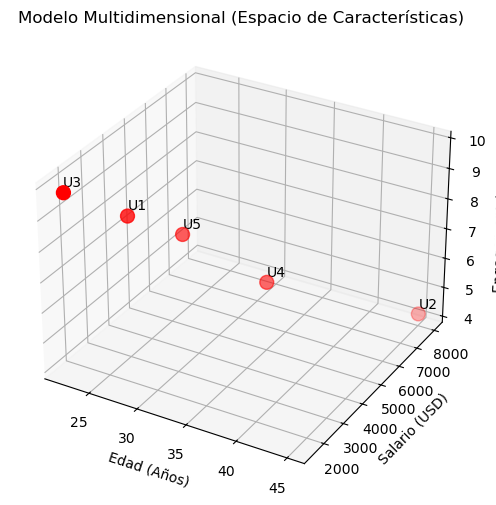

In [32]:
# Graficando el espacio 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Extraemos los ejes
x = df_X['Edad']
y = df_X['Salario']
z = df_X['Engagement']

# Ploteamos los puntos
scatter = ax.scatter(x, y, z, c='red', s=100, marker='o')

# Etiquetas del espacio
ax.set_xlabel('Edad (Años)')
ax.set_ylabel('Salario (USD)')
ax.set_zlabel('Engagement (Score)')
ax.set_title('Modelo Multidimensional (Espacio de Características)')

# Etiquetamos a cada usuario flotando
for i, txt in enumerate(df_X.index):
    ax.text(x[txt], y[txt], z[txt] + 0.2, txt, size=10, zorder=1, color='k')

plt.show()

---
### Manos a la obra (Responde aquí mismo)

**1. Mutación de la Matriz:**
Si el día de mañana el equipo de desarrollo de la app decide trackear 4 nuevas métricas de comportamiento (clicks, tiempo en pantalla, likes, compartidos) para nuestros mismos 5 usuarios, ¿cuáles serían los nuevos valores exactos de $n$ y $p$ para nuestra matriz $\mathbf{X}$?

> **Tu respuesta:** $n$ son los usuarios y $p$ serian las caracteristicas



**2. El Bug Geométrico:**
En la celda de cálculo de distancia euclidiana, notamos que la diferencia de salario (1500 de diferencia) aportó casi el 99% del valor de la distancia final, haciendo que la diferencia de edad (3 años) fuera matemáticamente invisible. ¿Qué técnica exacta de la Unidad II olvidamos aplicar sobre la matriz $\mathbf{X}$ antes de calcular la Norma L2 (Distancia Euclideana)?

> **Tu respuesta:** Falto estandarizacion o normalizacion de los datos. ya que las variables que son mas grandes sesgan los datos con menor valor



**3. El Límite Humano vs. Máquina:**
En el gráfico 3D pudimos visualizar perfectamente a los usuarios flotando. Si nuestra matriz de características tuviera $p=500$ columnas (por ejemplo, los píxeles de una foto de perfil), ¿cómo procesa la red neuronal este espacio de 500 dimensiones si físicamente no se puede graficar?

> **Tu respuesta:** La red neuronal procesa este espacio con algebra linear, la maquina no necesita graficar el espacio, solamente procesa vectores de 500 numeros.



**4. Eficiencia de Cómputo (Vectores vs Ciclos For):**
Como ingeniero de software, ¿por qué es computacionalmente más eficiente y rápido calcular la distancia entre miles de usuarios utilizando álgebra lineal (tensores con `numpy`) en lugar de extraer los datos y usar bucles `for` anidados para iterar sobre cada fila?

> **Tu respuesta:** Por la vectorizacion, ya que un ciclo for tiene un tiempo O demasiado grande, ya que tiene que iterar por cada uno de as filas. Mientras que numpy delega esa tarea a librerias optimizadas.

In [33]:
X_matriz = np.array([
    [25, 3000, 8.5],  # U1
    [45, 8000, 4.2],  # U2
    [22, 1500, 9.8],  # U3
    [35, 5000, 6.1],  # U4
    [28, 4200, 7.5]   # U5
], dtype=float)

In [34]:
u2 = X_matriz[1]
u4 = X_matriz[3]
dist_original = np.linalg.norm(u2 - u4)

print(f"Coordenadas U2: {u2}")
print(f"Coordenadas U4: {u4}")
print(f"Distancia euclidiana original: {dist_original:.2f}")

Coordenadas U2: [4.5e+01 8.0e+03 4.2e+00]
Coordenadas U4: [  35.  5000.     6.1]
Distancia euclidiana original: 3000.02


In [35]:
media = np.mean(X_matriz, axis=0)
desviacion = np.std(X_matriz, axis=0)
X_zscore = (X_matriz - media) / desviacion

df_zscore = pd.DataFrame(
    X_zscore,
    columns=['Edad', 'Salario', 'Engagement'],
    index=['U1', 'U2', 'U3', 'U4', 'U5']
)

print("\nMatriz X Estandarizada (Z-Score):")
display(df_zscore)


Matriz X Estandarizada (Z-Score):


,Edad,Salario,Engagement
U1,-0.729756,-0.615327,0.661024
U2,1.702765,1.680668,-1.559604
U3,-1.094635,-1.304125,1.332377
U4,0.486504,0.303071,-0.578396
U5,-0.364878,-0.064288,0.144599


In [36]:
u2_zscore = X_zscore[1]
u4_zscore = X_zscore[3]
dist_zscore = np.linalg.norm(u2_zscore - u4_zscore)

print(f"Distancia euclidiana estandarizada: {dist_zscore:.4f}")

Distancia euclidiana estandarizada: 2.0832
